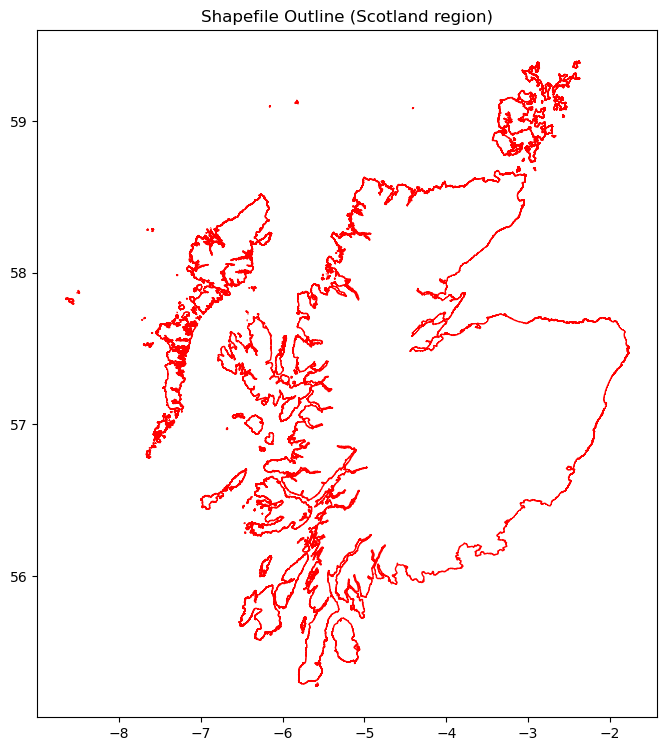

In [7]:
# Step 1: Visualize the shapefile and data grid overlay
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
shp_file = '/data/users/chantelle.burton/Attribution/StateOfFires_2025-26/SoW2526_Focal_MASTER_20260218.shp'
# Load the shapefile
shp = gpd.read_file(shp_file)
scotland = shp[shp['name'] == 'Scottish Highlands']
# Plot the shapefile
fig, ax = plt.subplots(figsize=(8, 10))
scotland.plot(ax=ax, edgecolor='red', facecolor='none')
ax.set_title('Shapefile Outline (Scotland region)')
plt.show()

Shapefile bounds: [-8.649996 55.274483 -1.76562  59.393142]
Shapefile CRS: EPSG:4326


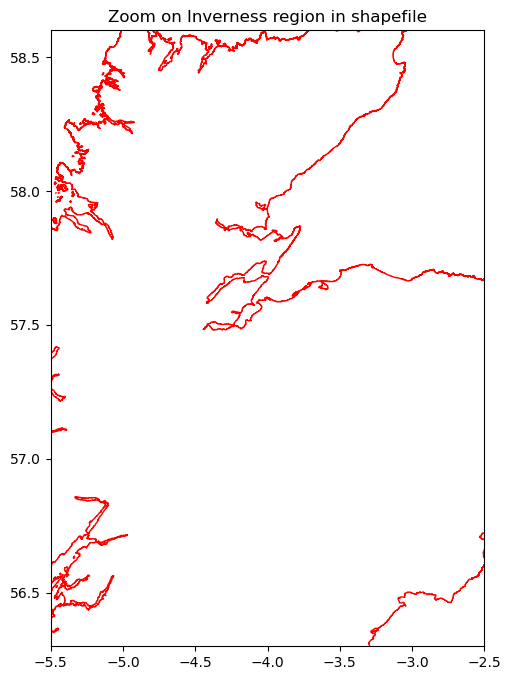

In [9]:
# Step 2: Check the shapefile geometry for Inverness region
# Print the bounds and plot the geometry for inspection
print('Shapefile bounds:', scotland.total_bounds)
print('Shapefile CRS:', scotland.crs)

# Optionally, zoom in on the Inverness area (approximate coordinates)
inverness_bbox = {
    'minx': -5.5, 'maxx': -2.5,  # Longitude
    'miny': 56.3, 'maxy': 58.6   # Latitude
}

fig, ax = plt.subplots(figsize=(8, 8))
scotland.plot(ax=ax, edgecolor='red', facecolor='none')
ax.set_xlim(inverness_bbox['minx'], inverness_bbox['maxx'])
ax.set_ylim(inverness_bbox['miny'], inverness_bbox['maxy'])
ax.set_title('Zoom on Inverness region in shapefile')
plt.show()

Latitude range: -90.0 90.0
Longitude range: 0.0 359.75


/home/users/bob.potts/.conda/envs/sowf/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/users/bob.potts/.conda/envs/sowf/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/users/bob.potts/.conda/envs/sowf/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:483: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().get_tightbbox(renderer, *args, **kwargs)
/home/users/bob.potts/.conda/envs/sowf/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/users/bob.potts/.conda/envs/sowf/lib/python3.12/site-packag

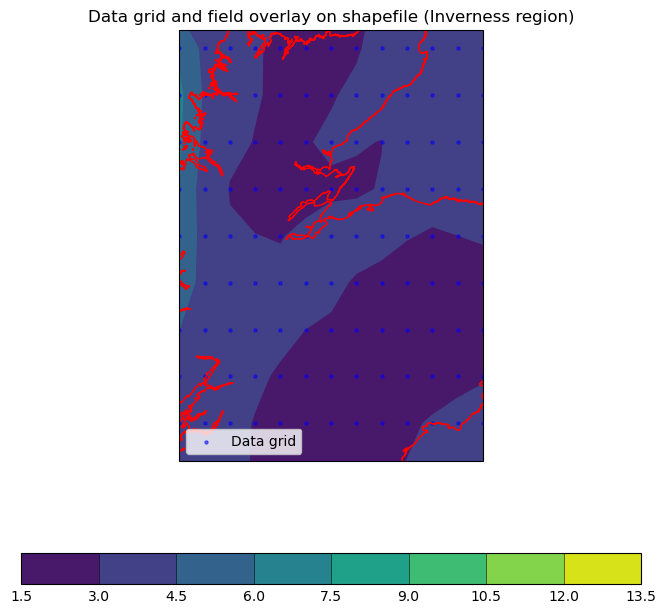

In [18]:
# Step 3: Overlay your data grid (before masking) on the shapefile (single time slice)
import numpy as np
import iris
import iris.quickplot as qplt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

file = '/data/scratch/andrew.hartley/impactstoolbox/Data/era5/Fire-Weather/FWI/FWI_ERA5_global_day_20230101-20230201.nc'
cube = iris.load(file)[0]

# Select the first time slice (assume time is the first dimension)
cube2d = cube[0, :, :] if cube.ndim == 3 else cube
lats = cube2d.coord('latitude').points
lons = cube2d.coord('longitude').points

print('Latitude range:', lats.min(), lats.max())
print('Longitude range:', lons.min(), lons.max())

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.PlateCarree()})
qplt.contourf(cube2d, axes=ax, cmap='viridis')
scotland.plot(ax=ax, edgecolor='red', facecolor='none', zorder=2, transform=ccrs.PlateCarree())

lon_grid, lat_grid = np.meshgrid(lons, lats)
ax.scatter(lon_grid.flatten(), lat_grid.flatten(), s=5, color='blue', alpha=0.5, zorder=1, label='Data grid', transform=ccrs.PlateCarree())

ax.set_xlim(inverness_bbox['minx'], inverness_bbox['maxx'])
ax.set_ylim(inverness_bbox['miny'], inverness_bbox['maxy'])
ax.set_title('Data grid and field overlay on shapefile (Inverness region)')
ax.legend()
plt.show()

In [20]:
# Test using intersects instead of contains for masking
from shapely import intersects

file = '/data/scratch/andrew.hartley/impactstoolbox/Data/era5/Fire-Weather/FWI/FWI_ERA5_global_day_20230101-20230201.nc'
cube = iris.load(file)[0]
cube2d = cube[0, :, :] if cube.ndim == 3 else cube
lats = cube2d.coord('latitude').points
lons = cube2d.coord('longitude').points
lon_grid, lat_grid = np.meshgrid(lons, lats)

# Get geometry for Scotland
geom = scotland.geometry.unary_union

# Mask using intersects
mask = ~intersects(geom, lon_grid, lat_grid)

masked_data = np.ma.masked_array(cube2d.data, mask=mask)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.PlateCarree()})
c = ax.pcolormesh(lon_grid, lat_grid, masked_data, cmap='viridis', shading='auto', transform=ccrs.PlateCarree())
scotland.plot(ax=ax, edgecolor='red', facecolor='none', zorder=2, transform=ccrs.PlateCarree())
ax.set_xlim(inverness_bbox['minx'], inverness_bbox['maxx'])
ax.set_ylim(inverness_bbox['miny'], inverness_bbox['maxy'])
ax.set_title('Masked with intersects (Inverness region)')
fig.colorbar(c, ax=ax, orientation='vertical', label='FWI')
plt.show()

/var/tmp/ipykernel_1952215/4027787771.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = scotland.geometry.unary_union


TypeError: intersects() takes 2 positional arguments but 3 were given

In [22]:
import iris
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
from shapely import contains, intersects

# List of region names
region_names = [
    'Northwest Iberia',
    'Midwestern Canadian Shield forests',
    'Chilean Temperate Forests and Matorral',
    'Scottish Highlands',
    'Southeast South Korea'
]

# Load shapefile and cube
shapefile = gpd.read_file(shp)
cubes = iris.load(file)
cube = cubes.extract('canadian_fire_weather_index')[0]

# Get a single time slice for visualization
cube2d = cube[0, :, :] if cube.ndim == 3 else cube
lats = cube2d.coord('latitude').points
lons = cube2d.coord('longitude').points
lon_grid, lat_grid = np.meshgrid(lons, lats)

fig, axs = plt.subplots(len(region_names), 2, figsize=(12, 4 * len(region_names)), subplot_kw={'projection': ccrs.PlateCarree()})

for i, region in enumerate(region_names):
    geom = shapefile[shapefile['name'] == region]['geometry'].values[0]

    # Mask with contains
    mask_contains = ~contains(geom, lon_grid, lat_grid)
    data_contains = np.ma.masked_array(cube2d.data, mask=mask_contains)
    axs[i, 0].set_title(f"{region}\nOriginal (contains)")
    im0 = axs[i, 0].pcolormesh(lon_grid, lat_grid, data_contains, cmap='viridis', shading='auto')
    shapefile[shapefile['name'] == region].plot(ax=axs[i, 0], edgecolor='red', facecolor='none', linewidth=2, zorder=2, transform=ccrs.PlateCarree())
    axs[i, 0].set_xlim(*geom.bounds[::2])
    axs[i, 0].set_ylim(*geom.bounds[1::2])

    # Mask with intersects
    mask_intersects = ~intersects(geom, lon_grid, lat_grid)
    data_intersects = np.ma.masked_array(cube2d.data, mask=mask_intersects)
    axs[i, 1].set_title(f"{region}\nNew (intersects)")
    im1 = axs[i, 1].pcolormesh(lon_grid, lat_grid, data_intersects, cmap='viridis', shading='auto')
    shapefile[shapefile['name'] == region].plot(ax=axs[i, 1], edgecolor='red', facecolor='none', linewidth=2, zorder=2, transform=ccrs.PlateCarree())
    axs[i, 1].set_xlim(*geom.bounds[::2])
    axs[i, 1].set_ylim(*geom.bounds[1::2])

plt.tight_layout()
plt.show()

DataSourceError: UID                                    name  \0    1                        Northwest Iberia   1    2      Midwestern Canadian Shield forests   2    3  Chilean Temperate Forests and Matorral   3    4                      Scottish Highlands   4    5                   Southeast South Korea                                               geometry  0  MULTIPOLYGON (((-8.05436 39.73539, -8.05438 39...  1  POLYGON ((-105.99854 59.28222, -105.99373 59.2...  2  MULTIPOLYGON (((-73.76165 -41.73915, -73.76159...  3  MULTIPOLYGON (((-7.63058 56.78917, -7.63085 56...  4  MULTIPOLYGON (((128.34526 34.55791, 128.3431 3...  : File name too long